In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import networkx as nx
import community.community_louvain as community_louvain

In [2]:
# Чтение файлов
df_interactions = pd.read_csv('interactions.csv')
df_items = pd.read_csv('items.csv')
df_users = pd.read_csv('users.csv')

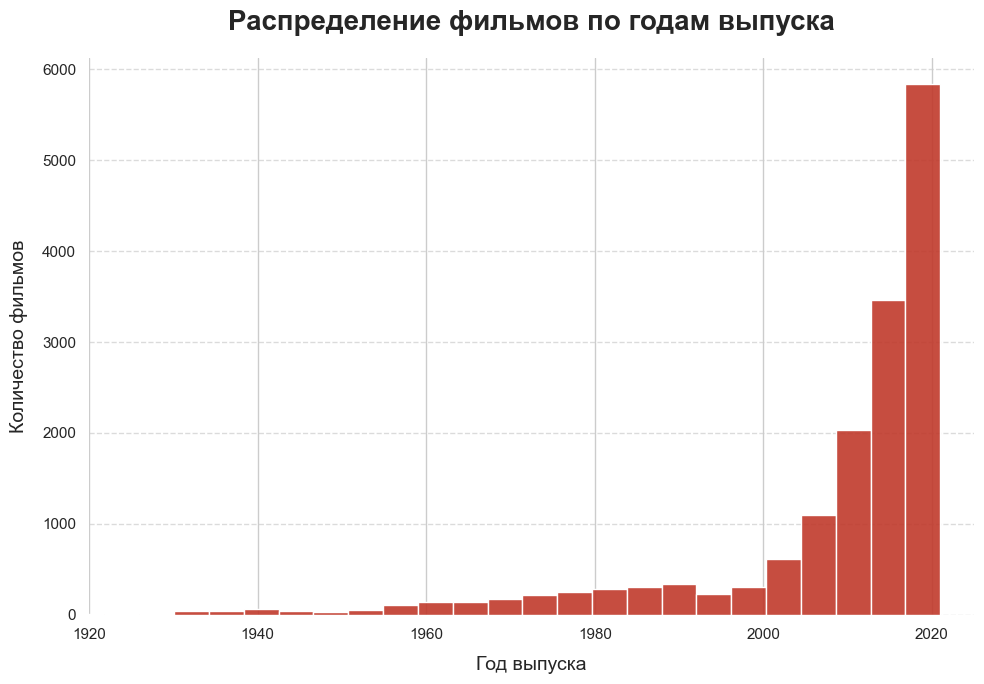

In [3]:
# График распределения фильмов по годам релиза
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 7))
ax = sns.histplot(data=df_items, x="release_year", bins=30, color="#C0392B", alpha=0.9, edgecolor="white")
plt.xlim(1920, 2025) 
plt.title("Распределение фильмов по годам выпуска", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Год выпуска", fontsize=14, labelpad=10)
plt.ylabel("Количество фильмов", fontsize=14, labelpad=10)
sns.despine(left=True, bottom=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

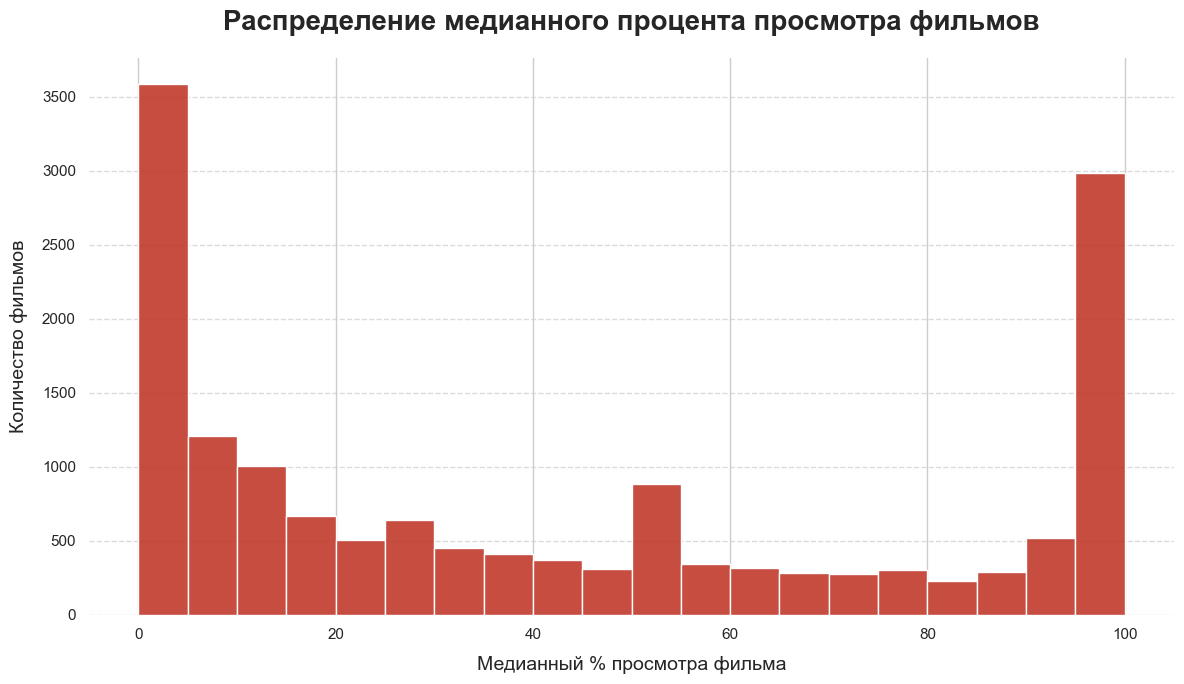

In [4]:
# График распределения фильмов по медианному проценту просмотра 
median_watched = df_interactions.groupby("item_id")["watched_pct"].median()

sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 7))
ax = sns.histplot(data=median_watched, bins=20, color="#C0392B", alpha=0.9, edgecolor="white")
plt.title("Распределение медианного процента просмотра фильмов", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Медианный % просмотра фильма", fontsize=14, labelpad=10)
plt.ylabel("Количество фильмов", fontsize=14, labelpad=10)
sns.despine(left=True, bottom=True) 
ax.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

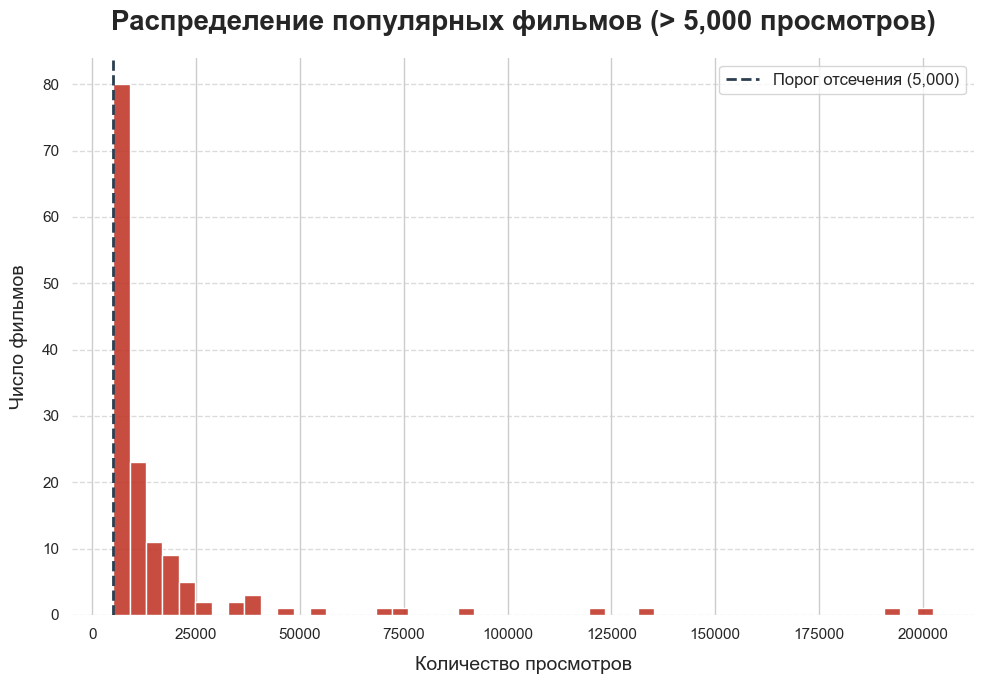

In [5]:
# График распределения фильмов по количеству уникальных зрителей с фильтрацией >5k. просмотров
view_counts = df_interactions.groupby("item_id")["user_id"].count()

threshold = 5000
filtered_counts = view_counts[view_counts > threshold]
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(10, 7))
ax = sns.histplot(x=filtered_counts.values, bins=50, color="#C0392B", alpha=0.9, edgecolor="white")
plt.title(f"Распределение популярных фильмов (> {threshold:,} просмотров)", fontsize=20, fontweight='bold', pad=20)
plt.xlabel("Количество просмотров", fontsize=14, labelpad=10)
plt.ylabel("Число фильмов", fontsize=14, labelpad=10)
plt.axvline(x=threshold, color='#2C3E50', linestyle='--', linewidth=2, label=f'Порог отсечения ({threshold:,})')
plt.legend(fontsize=12, loc='upper right') 
sns.despine(left=True, bottom=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
# Считаем агрегаты
stats = df_interactions.groupby('item_id')['watched_pct'].agg(['median', 'count']).reset_index()
stats.columns = ['item_id', 'median_watched_pct', 'view_count']

# Распределение числа уникальных просмотров
print(stats['view_count'].describe())
print()
# Распределение числа уникальных просмотров
print(stats['median_watched_pct'].describe())

count     15706.000000
mean        348.619827
std        3194.057581
min           0.000000
25%           3.000000
50%          12.000000
75%          99.000000
max      202457.000000
Name: view_count, dtype: float64

count    15605.000000
mean        42.272733
std         37.829322
min          0.000000
25%          6.000000
50%         32.000000
75%         82.500000
max        100.000000
Name: median_watched_pct, dtype: float64


In [7]:
# Фильтрация данных: фильмы старше 2000 г., медианный просмотра выше 25%, число зрителей больше 5000
# Применяем комбинированный фильтр
threshold_count = 5000 
threshold_median = 25.0
df_filtered_stats = stats[
    (stats['median_watched_pct'] > threshold_median) & 
    (stats['view_count'] >= threshold_count)
]

#  Мерджим с основным датасетом фильмов
df_items_filtered = df_items.merge(df_filtered_stats, on='item_id', how='inner')
df_final = df_items_filtered[df_items_filtered["release_year"] >= 2000]

print(f"Предварительное количество фильмов для анализа: {len(df_final)}")

Предварительное количество фильмов для анализа: 86


### Описательная статистика и финальная чистка

In [8]:
df_final.head()

,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,median_watched_pct,view_count
0,8447,film,Клуб «Кастет»,Knuckledust,2020.0,"боевики, триллеры","Великобритания, Франция",NaN,18.0,NaN,Джеймс Кермак,"Мо Данфорд, Кейт Дики, Гетин Энтони, Себастьен...",Бойцовский клуб «Кастет» – настоящая подпольна...,"2020, соединенное королевство, франция, клуб, ...",32.0,6762
1,3509,film,Комната желаний,The Room,2019.0,"драмы, фантастика, триллеры",Франция,NaN,16.0,NaN,Кристиан Волькман,"Ольга Куриленко, Кевин Янссенс, Джошуа Уилсон,...",Влюбленная пара решает переехать в уединенный ...,"психологический триллер, семья, реальность про...",67.0,5401
2,13915,film,Вперёд,Onward,2020.0,"для детей, приключения, семейное, фэнтези, ком...",США,NaN,6.0,NaN,Дэн Скэнлон,"Том Холланд, Крис Пратт, Джулия Луис-Дрейфус, ...","Когда-то давно в сказочном мире царила магия, ...","эльфы, мир фантазий, эльф, главный герой подро...",83.0,7526
3,12228,film,Волк с Уолл-стрит,The Wolf of Wall Street,2013.0,"драмы, биография, криминал, комедии",США,NaN,18.0,NaN,Мартин Скорсезе,"Леонардо ДиКаприо, Джона Хилл, Марго Робби, Ка...",1987 год. Джордан Белфорт становится брокером ...,"коррупция, наркомания, антигерой, аферист, мош...",40.0,5298
4,15399,series,Бывшие,NaN,2021.0,"драмы, мелодрамы",Россия,0.0,18.0,NaN,Иван Китаев,"Любовь Аксёнова, Денис Шведов, Полина Гагарина...",Яна выходит замуж за эксцентричного бизнесмена...,"Бывшие, 2021, Россия",28.0,5111


In [9]:
df_final.info()

<class 'pandas.DataFrame'>
Index: 86 entries, 0 to 87
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   item_id             86 non-null     int64  
 1   content_type        86 non-null     str    
 2   title               86 non-null     str    
 3   title_orig          81 non-null     str    
 4   release_year        86 non-null     float64
 5   genres              86 non-null     str    
 6   countries           86 non-null     str    
 7   for_kids            2 non-null      float64
 8   age_rating          86 non-null     float64
 9   studios             0 non-null      str    
 10  directors           86 non-null     str    
 11  actors              85 non-null     str    
 12  description         86 non-null     str    
 13  keywords            85 non-null     str    
 14  median_watched_pct  86 non-null     float64
 15  view_count          86 non-null     int64  
dtypes: float64(4), int64(2), s

- Удалим фильм с пустым значением по актерам

In [10]:
print(df_final[df_final["actors"].isna() == True])
df_final = df_final.dropna(subset=['actors']).reset_index(drop=True)

    item_id content_type  title title_orig  release_year          genres  \
19     6809         film  Дуров        NaN        2021.0  документальное   

   countries  for_kids  age_rating studios      directors actors  \
19    Россия       NaN        16.0     NaN  Родион Чепель    NaN   

                                          description  \
19  Уникальная история о лидере нового поколения, ...   

                                             keywords  median_watched_pct  \
19  Компьютер, Монитор, Гений, Интервью, Предприни...                48.0   

    view_count  
19       40372  


- Смотрим распределение фильмов по годам

In [11]:
df_final["release_year"].value_counts()

release_year
2020.0    24
2019.0    15
2021.0    12
2018.0    10
2015.0     5
2017.0     4
2013.0     3
2012.0     3
2009.0     2
2016.0     2
2014.0     1
2007.0     1
2003.0     1
2011.0     1
2001.0     1
Name: count, dtype: int64

- Смотрим распределение фильмов по типу контента

In [12]:
df_final["content_type"].value_counts()

content_type
film      81
series     4
Name: count, dtype: int64

### Подготовка данных

In [13]:
# Функция для подготовки и очистки данных. Этапы: приведение к единому разделителю, разбивка строки и приведение к единому формату, удаление дубликатов. 
def clean_and_split(text):
    text = str(text).replace('\n', ',')
    items = [item.strip().lower() for item in text.split(',')]
    return list(set([x for x in items if x]))

# Подготовка списков атрибутов
for col in ['actors', 'directors', 'genres']:
    df_final[f'{col}_list'] = df_final[col].apply(clean_and_split)

# Построение сети фильмов по жанрам
edges = []
genre_to_films = df_final.explode('genres_list').groupby('genres_list')['item_id'].apply(set).to_dict()

for genre, films in genre_to_films.items():
    films_list = list(films)
    
    # Создаем пары фильмов внутри каждого жанра
    from itertools import combinations
    for f1, f2 in combinations(films_list, 2):
        edges.append((f1, f2))

# Агрегация весов (количество общих жанров)
edge_df = pd.DataFrame(edges, columns=['film_1', 'film_2'])
edge_weights = edge_df.groupby(['film_1', 'film_2']).size().reset_index(name='weight')


Анализ чувствительности к выбору порога

In [14]:
thresholds = [1, 2, 3]
results = []

for t in thresholds:
    # Фильтрация ребер
    edge_filt = edge_weights[edge_weights['weight'] >= t]
    
    G_temp = nx.Graph()
    G_temp.add_weighted_edges_from(edge_filt[['film_1', 'film_2', 'weight']].itertuples(index=False))
    
    if G_temp.number_of_edges() == 0: continue
    
    # Расчет метрик
    partition = community_louvain.best_partition(G_temp, weight='weight', random_state=42)
    modularity = community_louvain.modularity(partition, G_temp, weight='weight')
    
    results.append({
        'threshold': t,
        'nodes': G_temp.number_of_nodes(),
        'edges': G_temp.number_of_edges(),
        'density': nx.density(G_temp),
        'communities': len(set(partition.values())),
        'modularity_Q': modularity
    })

pd.DataFrame(results).set_index('threshold')

,nodes,edges,density,communities,modularity_Q
threshold,,,,,
1,85,1708,0.478431,3,0.264200
2,71,378,0.152113,6,0.408296
3,37,84,0.126126,8,0.536083


In [15]:
edge_weights.to_pickle('edge_weights.pkl')
df_final.to_pickle('df_final.pkl')